# EDA — TSM Next-Day Direction Forecast (Stage 08)

Exploratory data analysis of the cleaned TSM daily data, using the
`src/eda.py` helpers from this stage. It profiles every column and plots the
time series, distributions and relationships that motivate the Stage 09
features.

Run top to bottom. It reads the processed dataset written by
`notebooks/project_pipeline.ipynb` (Stage 06).

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                    # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))     # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import pandas as pd
from src.config import DATA_DIR_PROCESSED, TICKER

df = pd.read_csv(DATA_DIR_PROCESSED / f'{TICKER.lower()}_processed.csv',
                 index_col='Date', parse_dates=True)
print('shape:', df.shape)
print('columns:', list(df.columns))
df.head()

shape: (1507, 11)
columns: ['adj_close', 'close', 'high', 'low', 'open', 'volume', 'return_1d', 'ma_5', 'ma_20', 'vol_20', 'target']


,adj_close,close,high,low,open,volume,return_1d,ma_5,ma_20,vol_20,target
Date,,,,,,,,,,,
2020-01-02,53.503265,60.040001,60.119999,59.599998,59.599998,8432600,NaN,NaN,NaN,NaN,0
2020-01-03,51.738834,58.060001,58.980000,58.040001,58.970001,10546400,-0.032978,NaN,NaN,NaN,0
2020-01-06,51.141785,57.389999,57.689999,57.130001,57.599998,8897200,-0.011540,NaN,NaN,NaN,1
2020-01-07,51.970535,58.320000,58.599998,56.740002,57.450001,7444300,0.016205,NaN,NaN,NaN,1
2020-01-08,52.353706,58.750000,58.980000,58.110001,58.189999,5381500,0.007373,58.512,NaN,NaN,1


## 1) Statistical summaries

Profile every column with `eda_summary()` (dtype, missingness, cardinality, and
mean / median / std / min / max / skew / kurtosis for numeric columns), then flag
anything that needs attention.

In [3]:
from src.eda import eda_summary, flag_columns
from IPython.display import display

display(eda_summary(df))
print('Columns needing attention:', flag_columns(df))

,dtype,n_missing,pct_missing,n_unique,mean,median,std,min,max,skew,kurtosis
adj_close,float64,0,0.0000,1481,1.215899e+02,1.033139e+02,6.033870e+01,3.948260e+01,3.077153e+02,1.2340,0.9503
close,float64,0,0.0000,1421,1.270210e+02,1.119000e+02,5.932590e+01,4.389000e+01,3.101400e+02,1.1976,0.9166
high,float64,0,0.0000,1411,1.286575e+02,1.134800e+02,6.014700e+01,4.518000e+01,3.139800e+02,1.1959,0.9159
low,float64,0,0.0000,1407,1.253929e+02,1.107500e+02,5.850000e+01,4.270000e+01,3.025000e+02,1.2022,0.9374
open,float64,0,0.0000,1398,1.271069e+02,1.122900e+02,5.942810e+01,4.374000e+01,3.109300e+02,1.2008,0.9366
volume,int64,0,0.0000,1495,1.194012e+07,1.050520e+07,6.409793e+06,2.753900e+06,6.866750e+07,3.0755,16.0246
return_1d,float64,1,0.0007,1505,1.400000e-03,5.000000e-04,2.450000e-02,-1.403000e-01,1.265000e-01,0.2382,3.2488
ma_5,float64,4,0.0027,1491,1.268809e+02,1.124000e+02,5.894440e+01,4.524600e+01,3.030260e+02,1.1933,0.9098
ma_20,float64,19,0.0126,1487,1.263833e+02,1.135792e+02,5.765190e+01,4.752450e+01,2.978865e+02,1.1857,0.9204
vol_20,float64,19,0.0126,1487,4.777600e+00,4.006800e+00,2.840400e+00,7.781000e-01,1.689650e+01,1.1384,1.1649


Columns needing attention: []


## 2) Time series

Price and volume over the sample. The dominant pattern is the multi-year uptrend
(close ~$60 in Jan 2020 to ~$300 in Dec 2025).

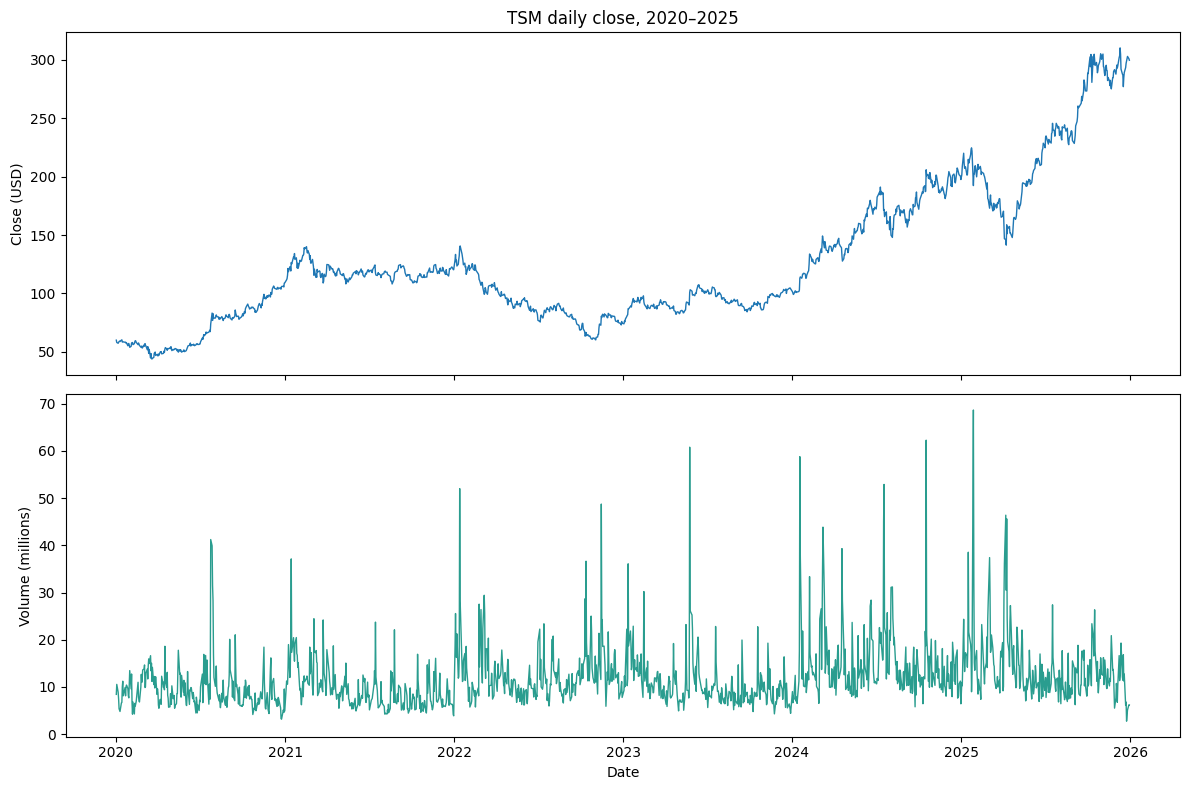

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(df.index, df['close'], linewidth=1)
ax1.set_ylabel('Close (USD)')
ax1.set_title('TSM daily close, 2020\u20132025')
ax2.plot(df.index, df['volume'] / 1e6, linewidth=1, color='#2a9d8f')
ax2.set_ylabel('Volume (millions)')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.show()

## 3) Distributions

The daily return is the modeling signal, so its shape matters most. It is mildly
right-skewed with fat tails (excess kurtosis > 0), consistent with the Stage 07
outlier analysis.

Daily return summary:
  mean     = 0.00137
  std      = 0.02450
  skew     = 0.238
  kurtosis = 3.249   (excess; >0 means fat tails)


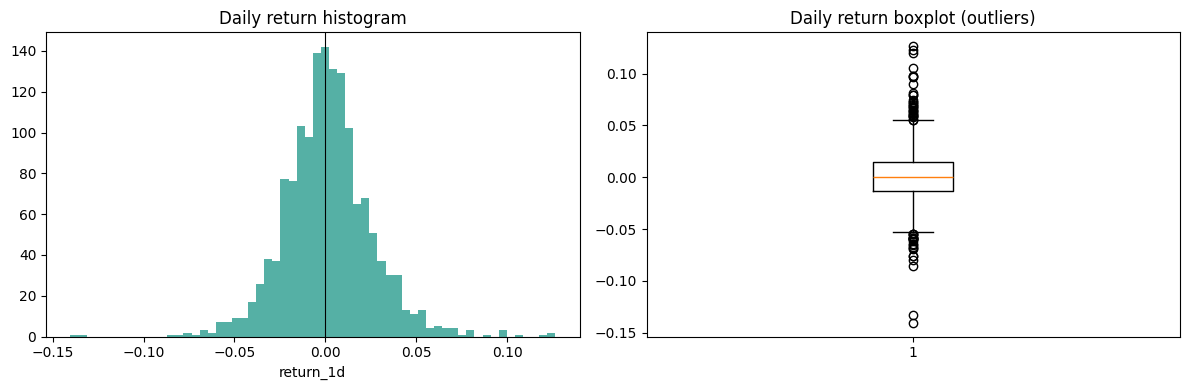

In [5]:
ret = df['return_1d'].dropna()

print('Daily return summary:')
print(f"  mean     = {ret.mean():.5f}")
print(f"  std      = {ret.std():.5f}")
print(f"  skew     = {ret.skew():.3f}")
print(f"  kurtosis = {ret.kurt():.3f}   (excess; >0 means fat tails)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ret, bins=60, alpha=0.8, color='#2a9d8f')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Daily return histogram')
axes[0].set_xlabel('return_1d')
axes[1].boxplot(ret, vert=True)
axes[1].set_title('Daily return boxplot (outliers)')
plt.tight_layout()
plt.show()

## 4) Relationships

Same-day return vs volume (scatter) and the correlation matrix of the numeric
features. Note how weakly the simple levels correlate with `target` — that is
why Stage 09 adds engineered features.

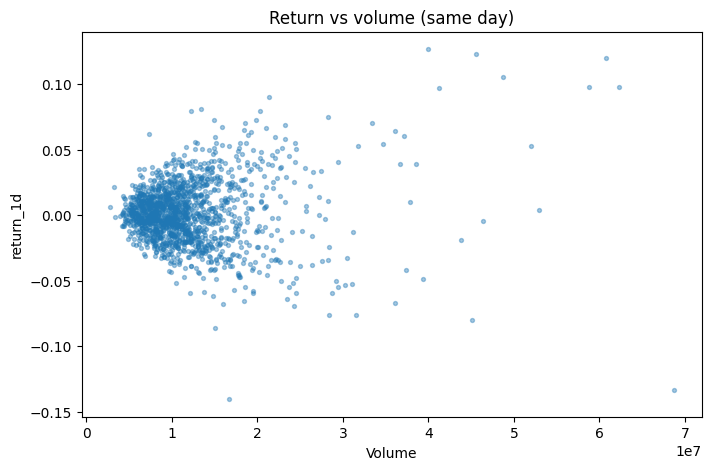

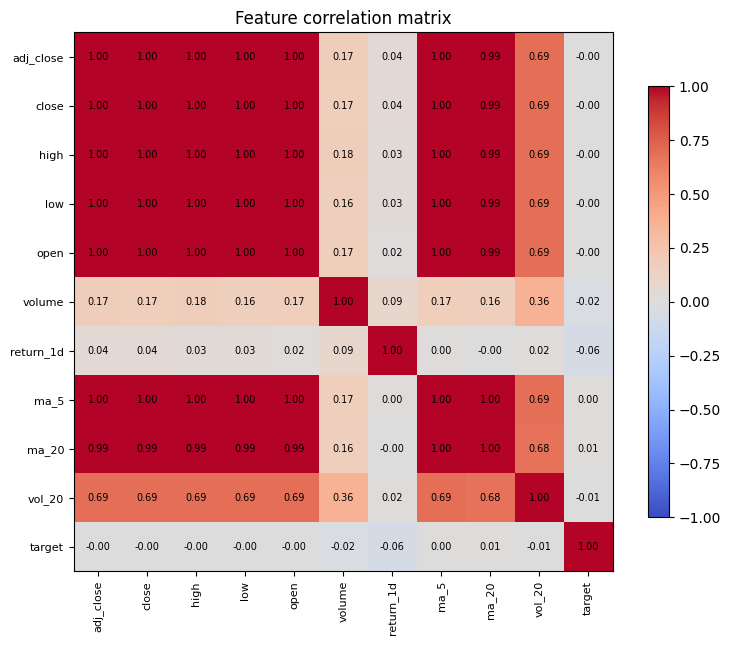

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['volume'], df['return_1d'], s=8, alpha=0.4)
ax.set_xlabel('Volume')
ax.set_ylabel('return_1d')
ax.set_title('Return vs volume (same day)')
plt.show()

corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature correlation matrix')
plt.show()

## 5) Insights & assumptions

### What the EDA shows
1. **Strong multi-year uptrend.** Close rises from ~$60 to ~$300 across the
   sample, so prices are non-stationary — models must work on returns / price
   ratios, not raw levels.
2. **Daily returns are mildly skewed with fat tails.** `return_1d` has skew ≈ 0.24
   and excess kurtosis ≈ 3.25, so large up- and down-days happen more often than a
   normal distribution predicts. This matches Stage 07: IQR flags 3.45% of days,
   z-score only 1.13%.
3. **The target is balanced** (~51% up / 49% down), so accuracy is a fair metric —
   a naive "always up" model would get only ~51%.

### Relationships → Stage 09 features
- **Weak mean reversion**: `return_1d` has lag-1 autocorrelation ≈ −0.11 — the
  thin edge a next-day model chases.
- **Levels don't correlate with direction**: `return_1d`, `ma_5`, `ma_20`, `vol_20`
  all have |corr| < 0.07 with `target`. Raw levels are nearly useless for
  direction, which motivates the Stage 09 engineered features (multi-horizon
  momentum, price-vs-MA position, volume surge, intraday range, overnight gap).

### Assumptions
- The 43 missing cells (~0.5%) come entirely from rolling-window warm-ups
  (`ma_5`/`ma_20`/`vol_20`/`return_1d`); raw OHLCV has **no** gaps, so no
  imputation is needed — drop the warm-up rows before modeling.
- Prices trend, so all features are computed on returns and price ratios.